# Depth Anything V2 - Metric Depth Estimation (VKITTI)

This notebook demonstrates how to use the **Depth Anything V2 Large** model trained on Virtual KITTI for metric depth estimation on outdoor scenes. The model outputs depth in meters with a max depth of 80m.

## 1. Install Dependencies and Clone Repository

In [1]:
# Verify OpenCV installation
try:
    import cv2
    print(f"✓ OpenCV version: {cv2.__version__}")
    print("✓ OpenCV imported successfully!")
except ImportError as e:
    print(f"✗ OpenCV import failed: {e}")
    print("\nTo fix this, rebuild the Docker container with:")
    print("  docker compose build --no-cache")
    print("  docker compose up -d")

✓ OpenCV version: 4.13.0
✓ OpenCV imported successfully!


In [4]:
# Clone the Depth Anything V2 repository
import os
import sys

# Check if repository already exists
if not os.path.exists('Depth-Anything-V2'):
    !git clone https://github.com/DepthAnything/Depth-Anything-V2.git
    print("Repository cloned successfully!")
else:
    print("Repository already exists!")

# Change to the metric depth directory
os.chdir('Depth-Anything-V2/metric_depth')
print(f"Current directory: {os.getcwd()}")

# Add to Python path
sys.path.insert(0, os.getcwd())

Repository already exists!
Current directory: /workspace/notebooks/Depth-Anything-V2/metric_depth


In [2]:
# Install required dependencies
!pip install -q opencv-python matplotlib torch torchvision timm

## 2. Import Required Libraries

In [5]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import urllib.request

from depth_anything_v2.dpt import DepthAnythingV2

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

xFormers not available
xFormers not available


PyTorch version: 2.9.1+cu128
CUDA available: True
CUDA device: NVIDIA GeForce RTX 5050 Laptop GPU


## 3. Download KITTI Sample Image

We'll download a sample image from the KITTI dataset for testing the depth estimation model.

Primary URL failed, trying fallback outdoor scene...
Downloaded outdoor scene image to kitti_sample.png


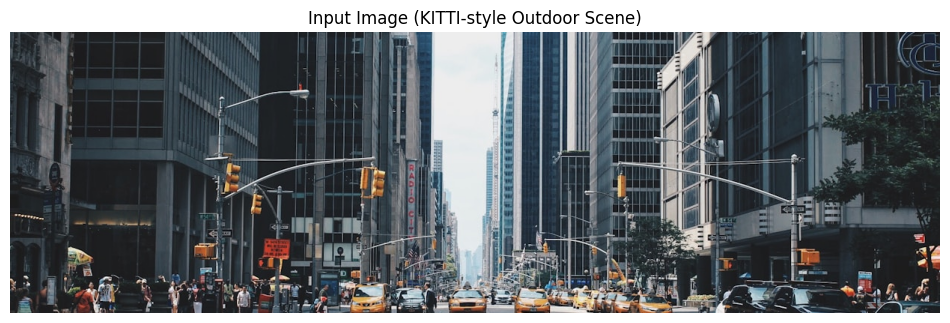

Image size: (1242, 375)


In [6]:
# Download a sample KITTI image
# Using a representative outdoor driving scene image
kitti_sample_url = "https://raw.githubusercontent.com/TRI-ML/vidar/main/media/kitti_sample.png"
sample_image_path = "kitti_sample.png"

# Alternative: use a typical outdoor scene if KITTI specific image is not available
fallback_url = "https://images.unsplash.com/photo-1449824913935-59a10b8d2000?w=1242&h=375&fit=crop"

try:
    urllib.request.urlretrieve(kitti_sample_url, sample_image_path)
    print(f"Downloaded KITTI sample image to {sample_image_path}")
except:
    print("Primary URL failed, trying fallback outdoor scene...")
    urllib.request.urlretrieve(fallback_url, sample_image_path)
    print(f"Downloaded outdoor scene image to {sample_image_path}")

# Display the image
img = Image.open(sample_image_path)
plt.figure(figsize=(12, 6))
plt.imshow(img)
plt.title("Input Image (KITTI-style Outdoor Scene)")
plt.axis('off')
plt.show()

print(f"Image size: {img.size}")

## 4. Load the Depth Anything V2 Model

We'll load the pre-trained VKITTI Large model from the models directory. This model is trained for outdoor scenes with a maximum depth of 80 meters.

In [7]:
# Model configuration
model_configs = {
    'vits': {'encoder': 'vits', 'features': 64, 'out_channels': [48, 96, 192, 384]},
    'vitb': {'encoder': 'vitb', 'features': 128, 'out_channels': [96, 192, 384, 768]},
    'vitl': {'encoder': 'vitl', 'features': 256, 'out_channels': [256, 512, 1024, 1024]}
}

# Configuration for VKITTI (outdoor scenes)
encoder = 'vitl'  # Large model
dataset = 'vkitti'  # Outdoor scenes
max_depth = 80  # Maximum depth in meters for outdoor scenes

# Path to the model checkpoint (now mounted in /workspace/models)
model_path = '/workspace/models/depth_anything_v2_metric_vkitti_vitl.pth'

print(f"Loading model: {encoder} trained on {dataset}")
print(f"Max depth: {max_depth} meters")

# Initialize the model
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

model = DepthAnythingV2(**{**model_configs[encoder], 'max_depth': max_depth})
model.load_state_dict(torch.load(model_path, map_location=device))
model = model.to(device)
model.eval()

print("Model loaded successfully!")

Loading model: vitl trained on vkitti
Max depth: 80 meters
Using device: cuda
Model loaded successfully!


## 5. Run Depth Estimation

Now we'll run the model on the sample image to get metric depth predictions in meters.

In [8]:
# Load the image using OpenCV
raw_img = cv2.imread(sample_image_path)
raw_img_rgb = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)

print(f"Input image shape: {raw_img.shape}")

# Run inference
print("Running depth estimation...")
with torch.no_grad():
    depth = model.infer_image(raw_img)  # HxW depth map in meters

print(f"Depth map shape: {depth.shape}")
print(f"Depth range: {depth.min():.2f}m to {depth.max():.2f}m")
print(f"Mean depth: {depth.mean():.2f}m")
print(f"Median depth: {np.median(depth):.2f}m")

Input image shape: (375, 1242, 3)
Running depth estimation...
Depth map shape: (375, 1242)
Depth range: 8.27m to 75.51m
Mean depth: 25.40m
Median depth: 21.55m


## 6. Visualize Results

Let's visualize the input image alongside the predicted depth map with metric scale.

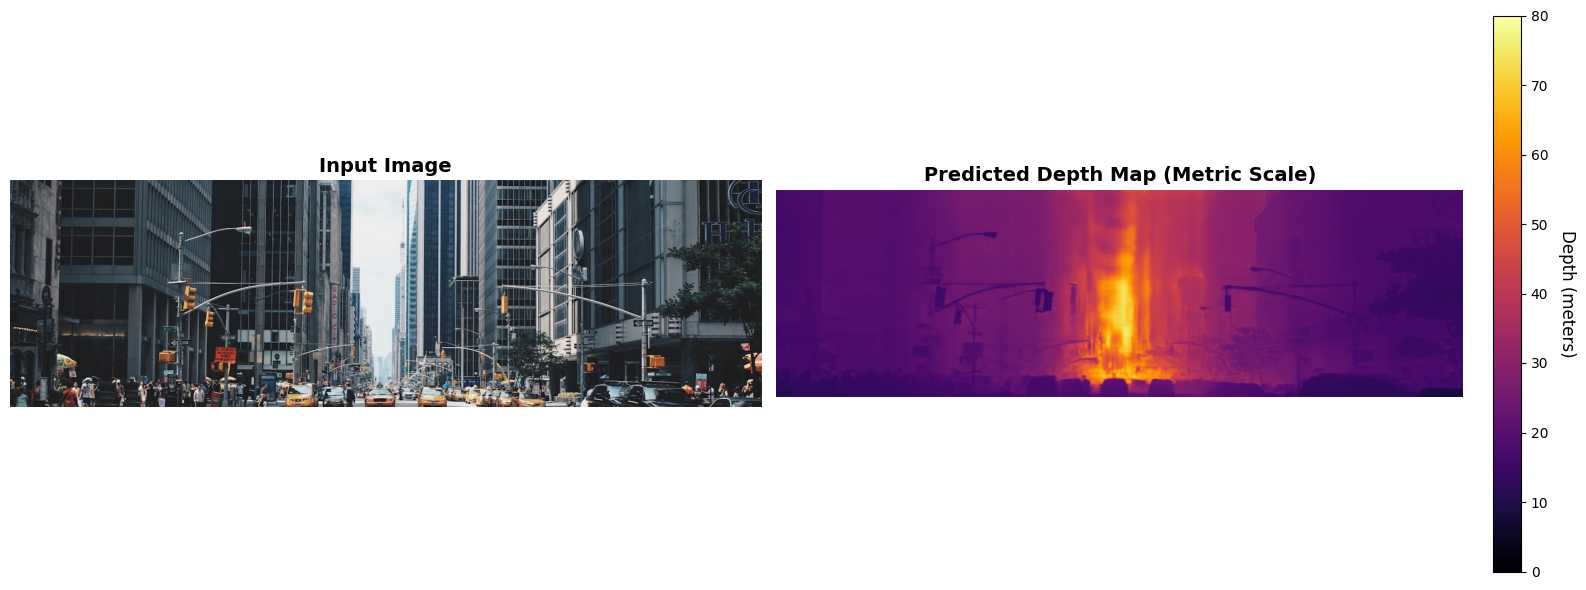

In [9]:
# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Original image
axes[0].imshow(raw_img_rgb)
axes[0].set_title('Input Image', fontsize=14, fontweight='bold')
axes[0].axis('off')

# Depth map with colorbar showing metric scale
im = axes[1].imshow(depth, cmap='inferno', vmin=0, vmax=max_depth)
axes[1].set_title('Predicted Depth Map (Metric Scale)', fontsize=14, fontweight='bold')
axes[1].axis('off')

# Add colorbar with metric scale
cbar = plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
cbar.set_label('Depth (meters)', rotation=270, labelpad=20, fontsize=12)

plt.tight_layout()
plt.show()

## 7. Additional Visualization - Depth Distribution

Let's analyze the depth distribution to better understand the scene geometry.

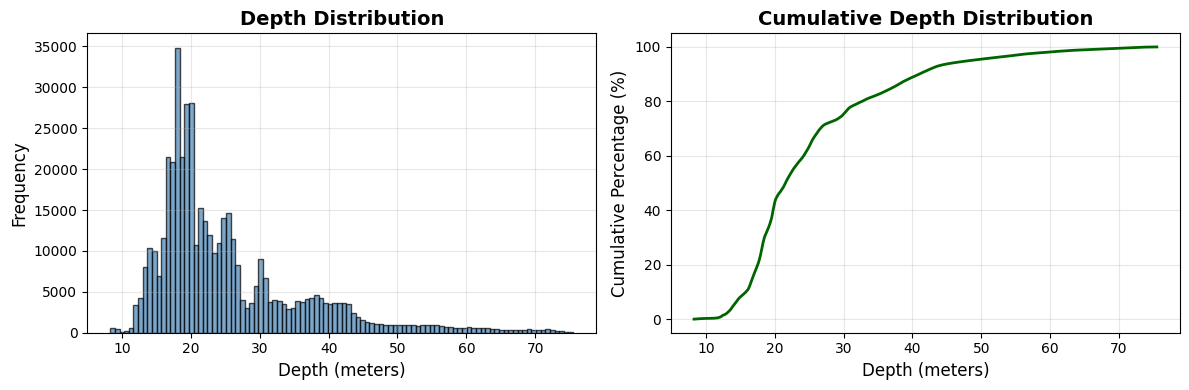


Depth Statistics (meters):
----------------------------------------
25th percentile: 18.06m
50th percentile: 21.55m
75th percentile: 29.89m
90th percentile: 40.97m
95th percentile: 48.35m
99th percentile: 65.13m


In [10]:
# Plot depth distribution histogram
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(depth.flatten(), bins=100, color='steelblue', edgecolor='black', alpha=0.7)
plt.xlabel('Depth (meters)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Depth Distribution', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Plot cumulative distribution
plt.subplot(1, 2, 2)
sorted_depth = np.sort(depth.flatten())
cumulative = np.arange(1, len(sorted_depth) + 1) / len(sorted_depth) * 100
plt.plot(sorted_depth, cumulative, linewidth=2, color='darkgreen')
plt.xlabel('Depth (meters)', fontsize=12)
plt.ylabel('Cumulative Percentage (%)', fontsize=12)
plt.title('Cumulative Depth Distribution', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print percentile statistics
percentiles = [25, 50, 75, 90, 95, 99]
print("\nDepth Statistics (meters):")
print("-" * 40)
for p in percentiles:
    value = np.percentile(depth, p)
    print(f"{p}th percentile: {value:.2f}m")

## 8. Save Results

Let's save the depth map as both a numpy array and a visualization image.

Saved depth map to: depth_map_metric.npy
Saved depth visualization to: depth_visualization.png
Saved comparison to: depth_comparison.png


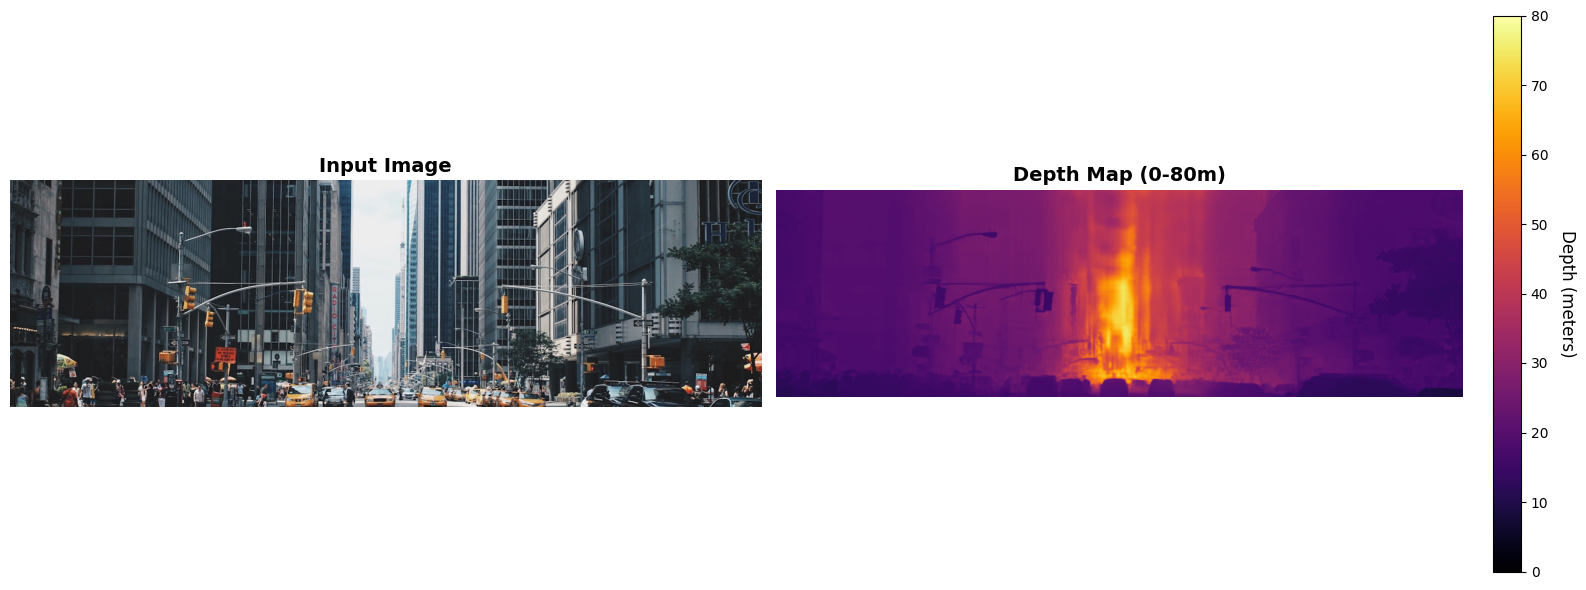

In [11]:
# Save depth map as numpy array
np.save('depth_map_metric.npy', depth)
print("Saved depth map to: depth_map_metric.npy")

# Save visualization
depth_normalized = (depth - depth.min()) / (depth.max() - depth.min())
depth_colored = plt.cm.inferno(depth_normalized)[:, :, :3]  # Remove alpha channel
depth_colored = (depth_colored * 255).astype(np.uint8)
cv2.imwrite('depth_visualization.png', cv2.cvtColor(depth_colored, cv2.COLOR_RGB2BGR))
print("Saved depth visualization to: depth_visualization.png")

# Save side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(raw_img_rgb)
axes[0].set_title('Input Image', fontsize=14, fontweight='bold')
axes[0].axis('off')

im = axes[1].imshow(depth, cmap='inferno', vmin=0, vmax=max_depth)
axes[1].set_title('Depth Map (0-80m)', fontsize=14, fontweight='bold')
axes[1].axis('off')

cbar = plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
cbar.set_label('Depth (meters)', rotation=270, labelpad=20, fontsize=12)

plt.tight_layout()
plt.savefig('depth_comparison.png', dpi=150, bbox_inches='tight')
print("Saved comparison to: depth_comparison.png")
plt.show()

## Summary

This notebook demonstrates the **Depth Anything V2** model for metric depth estimation on outdoor scenes:

- **Model**: ViT-Large encoder trained on Virtual KITTI dataset
- **Output**: Metric depth in meters (0-80m range)
- **Use Case**: Outdoor driving scenarios, similar to KITTI dataset
- **Key Features**:
  - Accurate metric depth prediction
  - Suitable for autonomous driving and robotics applications
  - Can be used for 3D scene reconstruction, obstacle detection, and navigation

The model outputs depth values in meters, making it suitable for applications requiring absolute depth measurements rather than relative depth.